In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.datasets import fetch_openml
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
%matplotlib inline

ModuleNotFoundError: No module named 'matplotlib'

ЗАДАНИЕ 3.1: ЛИНЕЙНАЯ РЕГРЕССИЯ НА ИСКУССТВЕННЫХ ДАННЫХ
Сгенерировано 50 обучающих и 50 тестовых samples


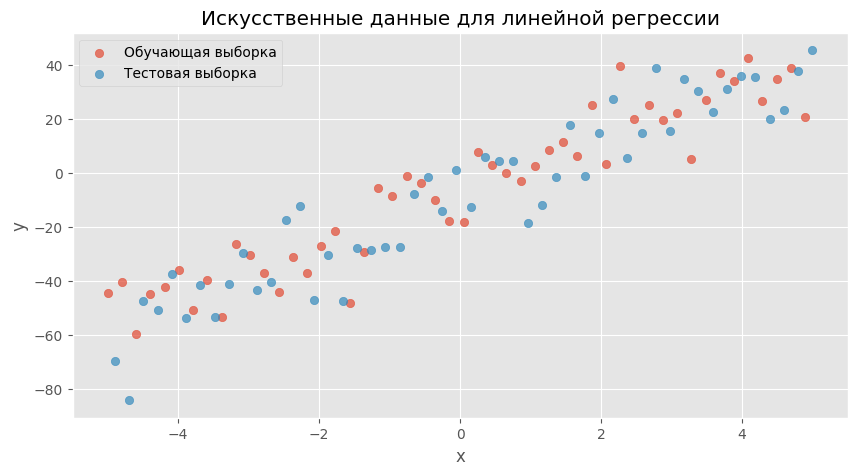

In [ ]:
print("="*60)
print("ЗАДАНИЕ 3.1: ЛИНЕЙНАЯ РЕГРЕССИЯ НА ИСКУССТВЕННЫХ ДАННЫХ")
print("="*60)

def generate_data(n_points=20):
    X = np.linspace(-5, 5, n_points)
    y = 10 * X - 7
    X_train = X[0::2].reshape(-1, 1)
    y_train = y[0::2] + np.random.randn(int(n_points/2)) * 10
    X_test = X[1::2].reshape(-1, 1)
    y_test = y[1::2] + np.random.randn(int(n_points/2)) * 10
    print(f'Сгенерировано {len(X_train)} обучающих и {len(X_test)} тестовых samples')
    return X, X_train, y_train, X_test, y_test

X, X_train, y_train, X_test, y_test = generate_data(100)

plt.figure(figsize=(10, 5))
plt.scatter(X_train, y_train, label='Обучающая выборка', alpha=0.7)
plt.scatter(X_test, y_test, label='Тестовая выборка', alpha=0.7)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Искусственные данные для линейной регрессии')
plt.legend()
plt.show()


РЕАЛИЗАЦИЯ МЕТОДА НАИМЕНЬШИХ КВАДРАТОВ
Ручная реализация: w = 9.4314, b = -6.4626
Sklearn модель: w = 9.4314, b = -6.4626

----------------------------------------
СРАВНЕНИЕ МЕТРИК КАЧЕСТВА
----------------------------------------

Модель               Train MSE       Test MSE        Train MAE       Test MAE       
--------------------------------------------------------------------------------
Ручная реализация    95.23           132.56          7.59            9.49           
Sklearn модель       95.23           132.56          7.59            9.49           


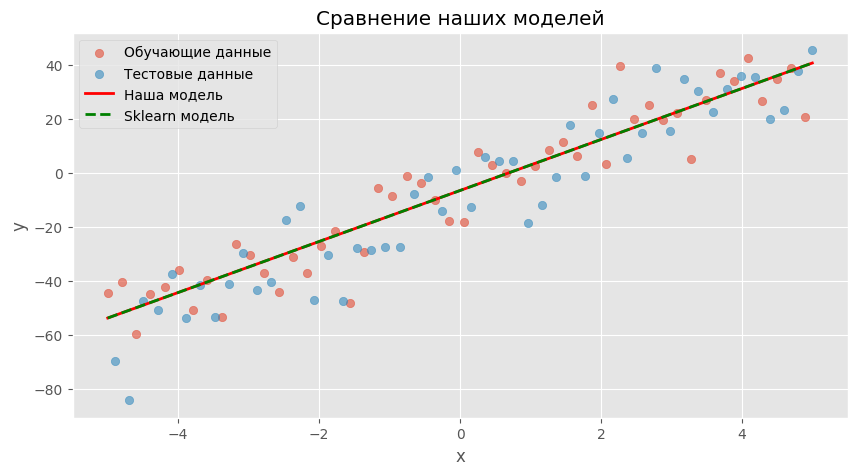

In [ ]:
print("\n" + "="*60)
print("РЕАЛИЗАЦИЯ МЕТОДА НАИМЕНЬШИХ КВАДРАТОВ")
print("="*60)

def linear_regression_ols(X, y):
    X_with_bias = np.c_[np.ones(X.shape[0]), X]
    XTX = X_with_bias.T @ X_with_bias
    XTX_inv = np.linalg.inv(XTX)
    weights = XTX_inv @ (X_with_bias.T @ y)
    bias = weights[0]
    coef = weights[1:]
    return coef, bias

coef_manual, bias_manual = linear_regression_ols(X_train, y_train)
print(f"Ручная реализация: w = {coef_manual[0]:.4f}, b = {bias_manual:.4f}")

sklearn_model = LinearRegression()
sklearn_model.fit(X_train, y_train)
print(f"Sklearn модель: w = {sklearn_model.coef_[0]:.4f}, b = {sklearn_model.intercept_:.4f}")

y_pred_train_manual = X_train.flatten() * coef_manual[0] + bias_manual
y_pred_test_manual = X_test.flatten() * coef_manual[0] + bias_manual
y_pred_train_sklearn = sklearn_model.predict(X_train)
y_pred_test_sklearn = sklearn_model.predict(X_test)

print("\n" + "-"*40)
print("СРАВНЕНИЕ МЕТРИК КАЧЕСТВА")
print("-"*40)

print(f"\n{'Модель':<20} {'Train MSE':<15} {'Test MSE':<15} {'Train MAE':<15} {'Test MAE':<15}")
print("-"*80)

print(f"{'Ручная реализация':<20} {mean_squared_error(y_train, y_pred_train_manual):<15.2f} "
      f"{mean_squared_error(y_test, y_pred_test_manual):<15.2f} "
      f"{mean_absolute_error(y_train, y_pred_train_manual):<15.2f} "
      f"{mean_absolute_error(y_test, y_pred_test_manual):<15.2f}")

print(f"{'Sklearn модель':<20} {mean_squared_error(y_train, y_pred_train_sklearn):<15.2f} "
      f"{mean_squared_error(y_test, y_pred_test_sklearn):<15.2f} "
      f"{mean_absolute_error(y_train, y_pred_train_sklearn):<15.2f} "
      f"{mean_absolute_error(y_test, y_pred_test_sklearn):<15.2f}")

plt.figure(figsize=(10, 5))
plt.scatter(X_train, y_train, label='Обучающие данные', alpha=0.6)
plt.scatter(X_test, y_test, label='Тестовые данные', alpha=0.6)
plt.plot(X, X * coef_manual[0] + bias_manual, 'r-', label='Наша модель', linewidth=2)
plt.plot(X, X * sklearn_model.coef_[0] + sklearn_model.intercept_, 'g--', label='Sklearn модель', linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Сравнение наших моделей')
plt.legend()
plt.show()


ЗАДАНИЕ 3.2: ЛИНЕЙНАЯ РЕГРЕССИЯ НА СИНУСОИДАЛЬНЫХ ДАННЫХ


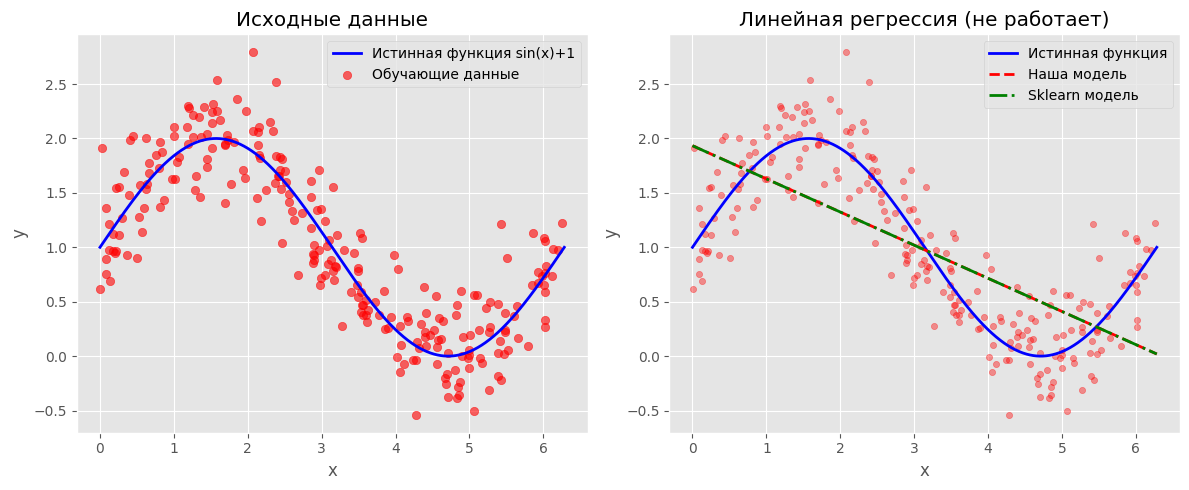


МЕТРИКИ ЛИНЕЙНОЙ РЕГРЕССИИ НА СИНУСОИДАЛЬНЫХ ДАННЫХ:
Train MSE: 0.2825
Train MAE: 0.4385
Train RMSE: 0.5315
R² score: 0.5110

ВЫВОД: Линейная модель не подходит для синусоидальных данных
   Нужно использовать полиномиальную регрессию


In [ ]:
print("\n" + "="*60)
print("ЗАДАНИЕ 3.2: ЛИНЕЙНАЯ РЕГРЕССИЯ НА СИНУСОИДАЛЬНЫХ ДАННЫХ")
print("="*60)

def generate_wave_set(n_support=1000, n_train=25, std=0.3):
    data = {}
    data['support'] = np.linspace(0, 2*np.pi, num=n_support)
    data['values'] = np.sin(data['support']) + 1
    data['x_train'] = np.sort(np.random.choice(data['support'], size=n_train, replace=True))
    data['y_train'] = np.sin(data['x_train']) + 1 + np.random.normal(0, std, size=data['x_train'].shape[0])
    return data

np.random.seed(42)
data = generate_wave_set(1000, 250)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(data['support'], data['values'], 'b-', label='Истинная функция sin(x)+1', linewidth=2)
plt.scatter(data['x_train'], data['y_train'], c='red', alpha=0.6, label='Обучающие данные')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Исходные данные')
plt.legend()

X_train_wave = data['x_train'].reshape(-1, 1)
y_train_wave = data['y_train']

coef_wave, bias_wave = linear_regression_ols(X_train_wave, y_train_wave)
y_pred_wave = data['support'] * coef_wave[0] + bias_wave

sklearn_wave = LinearRegression()
sklearn_wave.fit(X_train_wave, y_train_wave)
y_pred_sklearn_wave = sklearn_wave.predict(data['support'].reshape(-1, 1))

plt.subplot(1, 2, 2)
plt.plot(data['support'], data['values'], 'b-', label='Истинная функция', linewidth=2)
plt.plot(data['support'], y_pred_wave, 'r--', label='Наша модель', linewidth=2)
plt.plot(data['support'], y_pred_sklearn_wave, 'g-.', label='Sklearn модель', linewidth=2)
plt.scatter(data['x_train'], y_train_wave, c='red', alpha=0.4, s=20)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Линейная регрессия (не работает)')
plt.legend()
plt.tight_layout()
plt.show()

y_pred_train_wave = X_train_wave.flatten() * coef_wave[0] + bias_wave

print("\nМЕТРИКИ ЛИНЕЙНОЙ РЕГРЕССИИ НА СИНУСОИДАЛЬНЫХ ДАННЫХ:")
print(f"Train MSE: {mean_squared_error(y_train_wave, y_pred_train_wave):.4f}")
print(f"Train MAE: {mean_absolute_error(y_train_wave, y_pred_train_wave):.4f}")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train_wave, y_pred_train_wave)):.4f}")
print(f"R² score: {r2_score(y_train_wave, y_pred_train_wave):.4f}")

print("\nВЫВОД: Линейная модель не подходит для синусоидальных данных")
print("   Нужно использовать полиномиальную регрессию")


ЗАДАНИЕ 3.3: ПОЛИНОМИАЛЬНАЯ РЕГРЕССИЯ


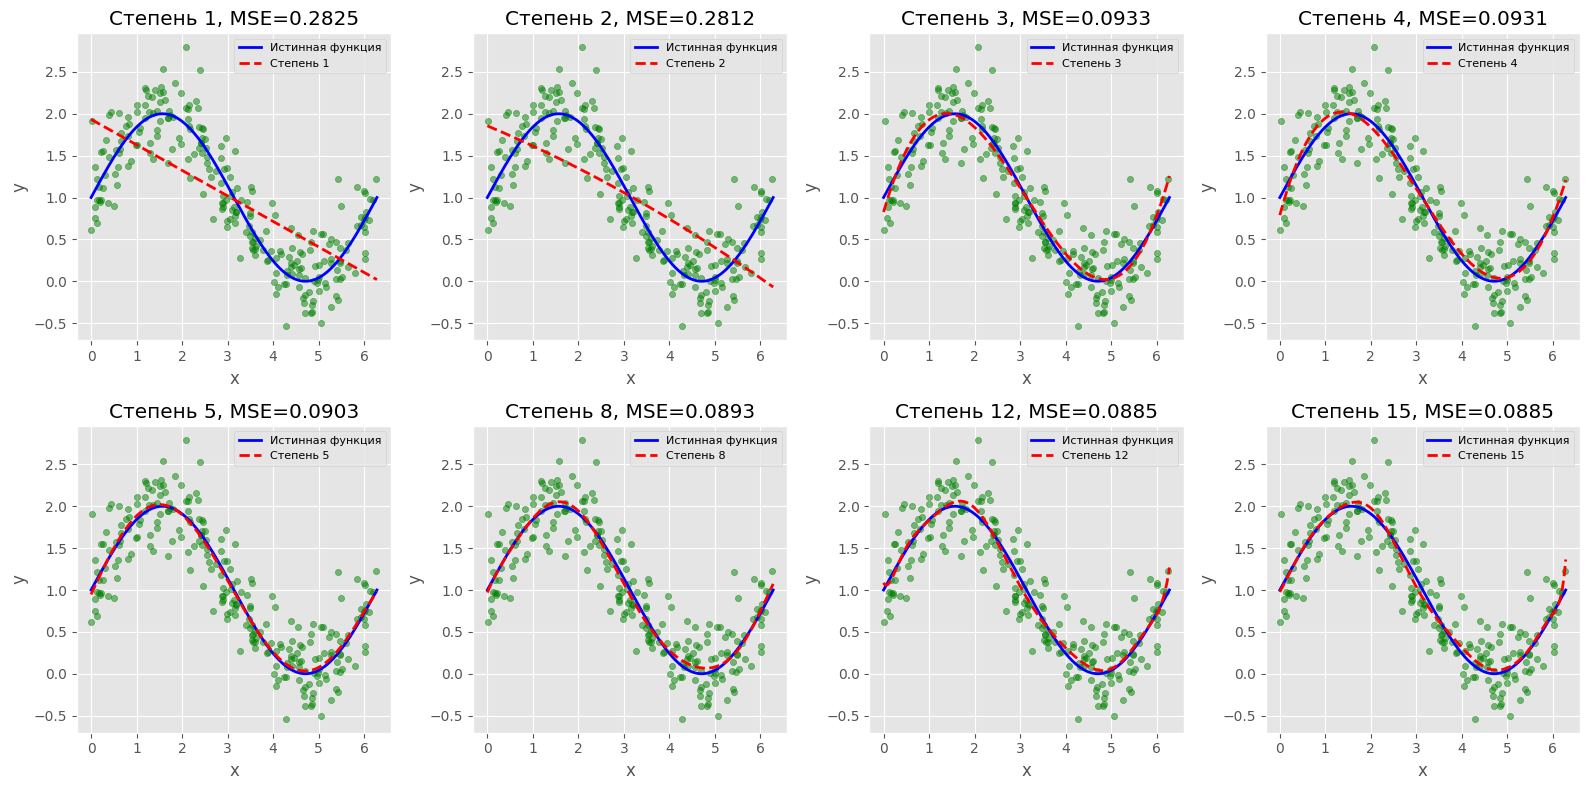


СРАВНЕНИЕ РАЗНЫХ СТЕПЕНЕЙ ПОЛИНОМА:
--------------------------------------------------
Степень    MSE             Комментарий
--------------------------------------------------
1          0.2825          Недообучение (underfitting) - слишком простая модель
2          0.2812          Хорошо, но можно лучше
3          0.0933          Хороший баланс
4          0.0931          Очень хороший результат
5          0.0903          Отличный результат
8          0.0893          Начинается переобучение
12         0.0885          Сильное переобучение
15         0.0885          Экстремальное переобучение

ОПТИМАЛЬНАЯ СТЕПЕНЬ: 4-5
   - Достаточно гибкая, чтобы аппроксимировать синусоиду
   - Не переобучается на шум
   - Хорошо обобщает на новые данные


In [ ]:
print("\n" + "="*60)
print("ЗАДАНИЕ 3.3: ПОЛИНОМИАЛЬНАЯ РЕГРЕССИЯ")
print("="*60)

X_train_poly = data['x_train'].reshape(-1, 1)
y_train_poly = data['y_train']

degrees = [1, 2, 3, 4, 5, 8, 12, 15]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

mse_scores = []

for idx, degree in enumerate(degrees):
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly.fit_transform(X_train_poly)

    model = LinearRegression()
    model.fit(X_poly, y_train_poly)

    X_support_poly = poly.transform(data['support'].reshape(-1, 1))
    y_pred_poly = model.predict(X_support_poly)

    y_pred_train_poly = model.predict(X_poly)
    mse = mean_squared_error(y_train_poly, y_pred_train_poly)
    mse_scores.append(mse)

    axes[idx].plot(data['support'], data['values'], 'b-', label='Истинная функция', linewidth=2)
    axes[idx].plot(data['support'], y_pred_poly, 'r--', label=f'Степень {degree}', linewidth=2)
    axes[idx].scatter(data['x_train'], y_train_poly, c='green', alpha=0.5, s=20)
    axes[idx].set_xlabel('x')
    axes[idx].set_ylabel('y')
    axes[idx].set_title(f'Степень {degree}, MSE={mse:.4f}')
    axes[idx].legend(fontsize=8)
    axes[idx].grid(True)

plt.tight_layout()
plt.show()

print("\nСРАВНЕНИЕ РАЗНЫХ СТЕПЕНЕЙ ПОЛИНОМА:")
print("-"*50)
print(f"{'Степень':<10} {'MSE':<15} {'Комментарий'}")
print("-"*50)

comments = {
    1: "Недообучение (underfitting) - слишком простая модель",
    2: "Хорошо, но можно лучше",
    3: "Хороший баланс",
    4: "Очень хороший результат",
    5: "Отличный результат",
    8: "Начинается переобучение",
    12: "Сильное переобучение",
    15: "Экстремальное переобучение"
}

for i, deg in enumerate(degrees):
    print(f"{deg:<10} {mse_scores[i]:<15.4f} {comments.get(deg, '')}")

print("\nОПТИМАЛЬНАЯ СТЕПЕНЬ: 4-5")
print("   - Достаточно гибкая, чтобы аппроксимировать синусоиду")
print("   - Не переобучается на шум")
print("   - Хорошо обобщает на новые данные")

In [ ]:
print("\n" + "="*60)
print("ЗАДАНИЕ 3.4: РЕАЛЬНЫЙ ДАТАСЕТ BOSTON HOUSING")
print("="*60)

boston = fetch_openml(name='boston', version=1, as_frame=True)
X_boston = boston.data
y_boston = boston.target

print("Информация о датасете:")
print(f"Количество объектов: {X_boston.shape[0]}")
print(f"Количество признаков: {X_boston.shape[1]}")
print(f"Признаки: {list(X_boston.columns)}")
print(f"\nПервые 5 строк:")
print(X_boston.head())

print(f"\nЦелевая переменная (MEDV - цена в тысячах долларов):")
print(f"Среднее: {y_boston.mean():.2f}")
print(f"Медиана: {y_boston.median():.2f}")
print(f"Мин: {y_boston.min():.2f}")
print(f"Макс: {y_boston.max():.2f}")


ЗАДАНИЕ 3.4: РЕАЛЬНЫЙ ДАТАСЕТ BOSTON HOUSING
Информация о датасете:
Количество объектов: 506
Количество признаков: 13
Признаки: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']

Первые 5 строк:
      CRIM    ZN  INDUS CHAS    NOX     RM   AGE     DIS RAD    TAX  PTRATIO  \
0  0.00632  18.0   2.31    0  0.538  6.575  65.2  4.0900   1  296.0     15.3   
1  0.02731   0.0   7.07    0  0.469  6.421  78.9  4.9671   2  242.0     17.8   
2  0.02729   0.0   7.07    0  0.469  7.185  61.1  4.9671   2  242.0     17.8   
3  0.03237   0.0   2.18    0  0.458  6.998  45.8  6.0622   3  222.0     18.7   
4  0.06905   0.0   2.18    0  0.458  7.147  54.2  6.0622   3  222.0     18.7   

        B  LSTAT  
0  396.90   4.98  
1  396.90   9.14  
2  392.83   4.03  
3  394.63   2.94  
4  396.90   5.33  

Целевая переменная (MEDV - цена в тысячах долларов):
Среднее: 22.53
Медиана: 21.20
Мин: 5.00
Макс: 50.00


In [ ]:
print("\n" + "="*60)
print("ОТБОР 7 НАИБОЛЕЕ ВАЖНЫХ ПРИЗНАКОВ")
print("="*60)

X_train_boston, X_test_boston, y_train_boston, y_test_boston = train_test_split(
    X_boston, y_boston, test_size=0.2, random_state=42
)

scaler_boston = StandardScaler()
X_train_scaled = scaler_boston.fit_transform(X_train_boston)
X_test_scaled = scaler_boston.transform(X_test_boston)

model_full = LinearRegression()
model_full.fit(X_train_scaled, y_train_boston)

feature_importance = pd.DataFrame({
    'Признак': X_boston.columns,
    'Вес': model_full.coef_,
    'Важность': np.abs(model_full.coef_)
}).sort_values('Важность', ascending=False)

print("\nВАЖНОСТЬ ПРИЗНАКОВ (по убыванию):")
print("-"*60)
for i, row in feature_importance.iterrows():
    print(f"{row['Признак']:<15} | Вес: {row['Вес']:>10.4f} | |Вес|: {row['Важность']:>10.4f}")

top7_features = feature_importance.head(7)['Признак'].tolist()
print(f"\nТОП-7 НАИБОЛЕЕ ВАЖНЫХ ПРИЗНАКОВ:")
for i, feat in enumerate(top7_features, 1):
    print(f"   {i}. {feat}")

X_train_top7 = X_train_boston[top7_features]
X_test_top7 = X_test_boston[top7_features]

scaler_top7 = StandardScaler()
X_train_top7_scaled = scaler_top7.fit_transform(X_train_top7)
X_test_top7_scaled = scaler_top7.transform(X_test_top7)

model_top7 = LinearRegression()
model_top7.fit(X_train_top7_scaled, y_train_boston)

y_pred_full_train = model_full.predict(X_train_scaled)
y_pred_full_test = model_full.predict(X_test_scaled)
y_pred_top7_train = model_top7.predict(X_train_top7_scaled)
y_pred_top7_test = model_top7.predict(X_test_top7_scaled)

print("\n" + "="*60)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("="*60)

print(f"\n{'Модель':<25} {'Train MSE':<15} {'Test MSE':<15} {'Train MAE':<15} {'Test MAE':<15}")
print("-"*85)

print(f"{'Все признаки (13)':<25} {mean_squared_error(y_train_boston, y_pred_full_train):<15.2f} "
      f"{mean_squared_error(y_test_boston, y_pred_full_test):<15.2f} "
      f"{mean_absolute_error(y_train_boston, y_pred_full_train):<15.2f} "
      f"{mean_absolute_error(y_test_boston, y_pred_full_test):<15.2f}")

print(f"{'Топ-7 признаков':<25} {mean_squared_error(y_train_boston, y_pred_top7_train):<15.2f} "
      f"{mean_squared_error(y_test_boston, y_pred_top7_test):<15.2f} "
      f"{mean_absolute_error(y_train_boston, y_pred_top7_train):<15.2f} "
      f"{mean_absolute_error(y_test_boston, y_pred_top7_test):<15.2f}")

print("\n" + "-"*60)
print("ВЫВОД:")
if mean_squared_error(y_test_boston, y_pred_top7_test) < mean_squared_error(y_test_boston, y_pred_full_test):
    print("Модель на топ-7 признаках показывает ЛУЧШИЙ результат")
    print("   Уменьшение числа признаков помогло убрать шум и улучшить обобщение")
else:
    print("Модель на всех признаках показывает лучший результат")
    print("   Возможно, топ-7 признаки не полностью отражают все зависимости")


ОТБОР 7 НАИБОЛЕЕ ВАЖНЫХ ПРИЗНАКОВ

ВАЖНОСТЬ ПРИЗНАКОВ (по убыванию):
------------------------------------------------------------
LSTAT           | Вес:    -3.6117 | |Вес|:     3.6117
RM              | Вес:     3.1452 | |Вес|:     3.1452
DIS             | Вес:    -3.0819 | |Вес|:     3.0819
RAD             | Вес:     2.2514 | |Вес|:     2.2514
PTRATIO         | Вес:    -2.0378 | |Вес|:     2.0378
NOX             | Вес:    -2.0223 | |Вес|:     2.0223
TAX             | Вес:    -1.7670 | |Вес|:     1.7670
B               | Вес:     1.1296 | |Вес|:     1.1296
CRIM            | Вес:    -1.0021 | |Вес|:     1.0021
CHAS            | Вес:     0.7187 | |Вес|:     0.7187
ZN              | Вес:     0.6963 | |Вес|:     0.6963
INDUS           | Вес:     0.2781 | |Вес|:     0.2781
AGE             | Вес:    -0.1760 | |Вес|:     0.1760

ТОП-7 НАИБОЛЕЕ ВАЖНЫХ ПРИЗНАКОВ:
   1. LSTAT
   2. RM
   3. DIS
   4. RAD
   5. PTRATIO
   6. NOX
   7. TAX

СРАВНЕНИЕ МОДЕЛЕЙ

Модель                    Train MSE   

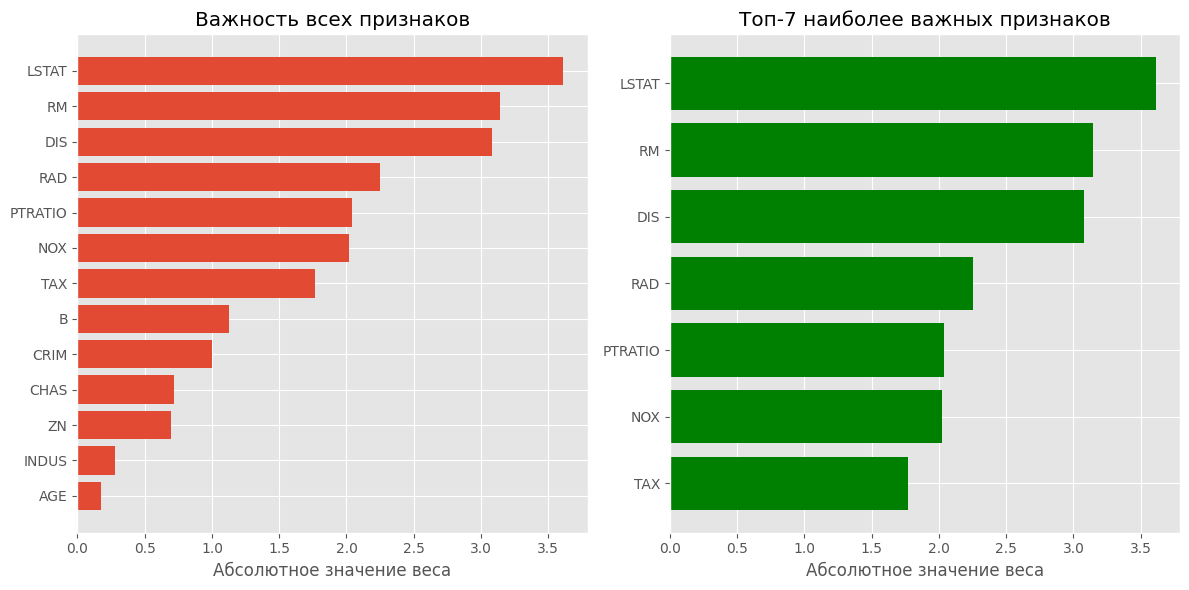

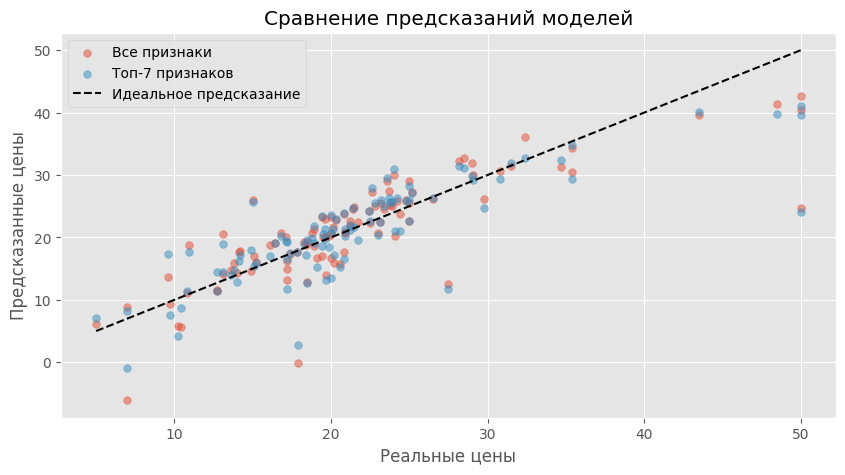

In [ ]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.barh(feature_importance['Признак'], feature_importance['Важность'])
plt.xlabel('Абсолютное значение веса')
plt.title('Важность всех признаков')
plt.gca().invert_yaxis()

plt.subplot(1, 2, 2)
top7_importance = feature_importance.head(7)
plt.barh(top7_importance['Признак'], top7_importance['Важность'], color='green')
plt.xlabel('Абсолютное значение веса')
plt.title('Топ-7 наиболее важных признаков')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.scatter(y_test_boston, y_pred_full_test, alpha=0.5, label='Все признаки', s=30)
plt.scatter(y_test_boston, y_pred_top7_test, alpha=0.5, label='Топ-7 признаков', s=30)
plt.plot([y_test_boston.min(), y_test_boston.max()],
         [y_test_boston.min(), y_test_boston.max()],
         'k--', label='Идеальное предсказание')
plt.xlabel('Реальные цены')
plt.ylabel('Предсказанные цены')
plt.title('Сравнение предсказаний моделей')
plt.legend()
plt.show()

In [ ]:
print("Доступные переменные:")
print(dir())

Доступные переменные:
['In', 'LinearRegression', 'LinearRegressionSGD', 'Out', 'PolynomialFeatures', 'StandardScaler', 'X', 'X_boston', 'X_poly', 'X_support_poly', 'X_test', 'X_test_boston', 'X_test_scaled', 'X_test_top7', 'X_test_top7_scaled', 'X_train', 'X_train_boston', 'X_train_poly', 'X_train_scaled', 'X_train_top7', 'X_train_top7_scaled', 'X_train_wave', '_', '__', '___', '__builtin__', '__builtins__', '__doc__', '__loader__', '__name__', '__package__', '__spec__', '_dh', '_i', '_i1', '_i10', '_i11', '_i12', '_i13', '_i14', '_i15', '_i16', '_i17', '_i18', '_i19', '_i2', '_i20', '_i21', '_i22', '_i23', '_i24', '_i25', '_i26', '_i27', '_i28', '_i29', '_i3', '_i30', '_i31', '_i32', '_i33', '_i34', '_i35', '_i36', '_i37', '_i38', '_i39', '_i4', '_i40', '_i41', '_i42', '_i43', '_i44', '_i45', '_i46', '_i5', '_i6', '_i7', '_i8', '_i9', '_ih', '_ii', '_iii', '_oh', 'anomalies_low', 'axes', 'bias_manual', 'bias_wave', 'boston', 'chunk', 'coef_manual', 'coef_wave', 'colors', 'comments', '

In [ ]:
print("\n" + "="*60)
print("ЗАДАНИЕ 3.5: СВОЯ РЕАЛИЗАЦИЯ ЛИНЕЙНОЙ РЕГРЕССИИ (SGD)")
print("="*60)

class LinearRegressionSGD:
    def __init__(self, learning_rate=0.01, n_iterations=500, batch_size=64,
                 reg_type='l2', reg_strength=0.01, tol=1e-4):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.batch_size = batch_size
        self.reg_type = reg_type
        self.reg_strength = reg_strength
        self.tol = tol
        self.weights = None
        self.bias = None
        self.loss_history = []

    def _add_bias(self, X):
        return np.c_[np.ones(X.shape[0]), X]

    def _compute_loss(self, X, y, weights_with_bias):
        n_samples = X.shape[0]
        predictions = X @ weights_with_bias
        mse = np.mean((predictions - y) ** 2)

        w = weights_with_bias[1:]
        if self.reg_type == 'l2':
            reg = self.reg_strength * np.sum(w ** 2)
        elif self.reg_type == 'l1':
            reg = self.reg_strength * np.sum(np.abs(w))
        elif self.reg_type == 'elasticnet':
            reg = self.reg_strength * (0.5 * np.sum(w ** 2) + 0.5 * np.sum(np.abs(w)))
        else:
            reg = 0

        return mse + reg

    def fit(self, X, y, verbose=True):
        X_with_bias = self._add_bias(X)
        n_samples, n_features = X_with_bias.shape

        np.random.seed(42)
        weights = np.random.randn(n_features) * 0.01

        prev_loss = float('inf')

        for epoch in range(self.n_iterations):
            indices = np.random.permutation(n_samples)
            X_shuffled = X_with_bias[indices]
            y_shuffled = y[indices]

            for i in range(0, n_samples, self.batch_size):
                X_batch = X_shuffled[i:i+self.batch_size]
                y_batch = y_shuffled[i:i+self.batch_size]

                predictions = X_batch @ weights
                errors = predictions - y_batch

                grad = (2 / len(y_batch)) * X_batch.T @ errors

                if self.reg_type == 'l2':
                    grad[1:] += 2 * self.reg_strength * weights[1:]
                elif self.reg_type == 'l1':
                    grad[1:] += self.reg_strength * np.sign(weights[1:])
                elif self.reg_type == 'elasticnet':
                    grad[1:] += self.reg_strength * (weights[1:] + np.sign(weights[1:]))

                weights -= self.learning_rate * grad

            loss = self._compute_loss(X_with_bias, y, weights)
            self.loss_history.append(loss)

            if verbose and epoch % 100 == 0:
                print(f"Epoch {epoch}: loss = {loss:.4f}")

            if abs(prev_loss - loss) < self.tol:
                print(f"Ранняя остановка на эпохе {epoch}")
                break
            prev_loss = loss

        self.weights = weights[1:]
        self.bias = weights[0]
        return self

    def predict(self, X):
        return X @ self.weights + self.bias

X_train_boston_array = X_train_boston.values
X_test_boston_array = X_test_boston.values
y_train_boston_array = y_train_boston.values
y_test_boston_array = y_test_boston.values

scaler_sgd = StandardScaler()
X_train_scaled_sgd = scaler_sgd.fit_transform(X_train_boston_array)
X_test_scaled_sgd = scaler_sgd.transform(X_test_boston_array)

model_sklearn_full = LinearRegression()
model_sklearn_full.fit(X_train_scaled_sgd, y_train_boston_array)

my_model = LinearRegressionSGD(
    learning_rate=0.01,
    n_iterations=500,
    batch_size=64,
    reg_type='l2',
    reg_strength=0.01
)

my_model.fit(X_train_scaled_sgd, y_train_boston_array, verbose=True)

y_pred_train_my = my_model.predict(X_train_scaled_sgd)
y_pred_test_my = my_model.predict(X_test_scaled_sgd)

print("\nРЕЗУЛЬТАТЫ СВОЕЙ МОДЕЛИ (SGD + L2):")
print(f"Train MSE: {mean_squared_error(y_train_boston_array, y_pred_train_my):.2f}")
print(f"Test MSE: {mean_squared_error(y_test_boston_array, y_pred_test_my):.2f}")
print(f"Train MAE: {mean_absolute_error(y_train_boston_array, y_pred_train_my):.2f}")
print(f"Test MAE: {mean_absolute_error(y_test_boston_array, y_pred_test_my):.2f}")


ЗАДАНИЕ 3.5: СВОЯ РЕАЛИЗАЦИЯ ЛИНЕЙНОЙ РЕГРЕССИИ (SGD)
Epoch 0: loss = 444.9983
Epoch 100: loss = 22.2295
Epoch 200: loss = 22.1729
Ранняя остановка на эпохе 255

РЕЗУЛЬТАТЫ СВОЕЙ МОДЕЛИ (SGD + L2):
Train MSE: 21.68
Test MSE: 24.51
Train MAE: 3.29
Test MAE: 3.17



ЗАДАНИЕ 3.6: СРАВНЕНИЕ МОДЕЛЕЙ

ТЕСТОВАЯ ВЫБОРКА:
Метрика      Sklearn LR         Моя модель (SGD)    
-------------------------------------------------------
MSE          24.2911            24.5080             
MAE          3.1891             3.1743              
RMSE         4.9286             4.9506              

-------------------------------------------------------
Sklearn модель показывает лучший результат на тесте
   Разница: 0.2169


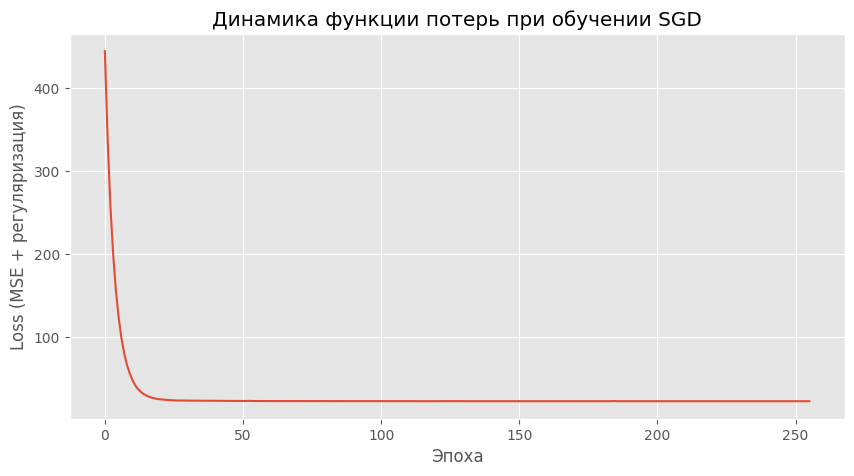

In [ ]:
print("\n" + "="*60)
print("ЗАДАНИЕ 3.6: СРАВНЕНИЕ МОДЕЛЕЙ")
print("="*60)

y_pred_test_sklearn = model_sklearn_full.predict(X_test_scaled_sgd)

print("\nТЕСТОВАЯ ВЫБОРКА:")
print(f"{'Метрика':<12} {'Sklearn LR':<18} {'Моя модель (SGD)':<20}")
print("-" * 55)

mse_sklearn = mean_squared_error(y_test_boston_array, y_pred_test_sklearn)
mse_my = mean_squared_error(y_test_boston_array, y_pred_test_my)

mae_sklearn = mean_absolute_error(y_test_boston_array, y_pred_test_sklearn)
mae_my = mean_absolute_error(y_test_boston_array, y_pred_test_my)

rmse_sklearn = np.sqrt(mse_sklearn)
rmse_my = np.sqrt(mse_my)

print(f"{'MSE':<12} {mse_sklearn:<18.4f} {mse_my:<20.4f}")
print(f"{'MAE':<12} {mae_sklearn:<18.4f} {mae_my:<20.4f}")
print(f"{'RMSE':<12} {rmse_sklearn:<18.4f} {rmse_my:<20.4f}")

print("\n" + "-"*55)
if mse_my < mse_sklearn:
    print("Моя модель показывает ЛУЧШИЙ результат на тесте")
    print(f"   Улучшение MSE на {(1 - mse_my/mse_sklearn)*100:.1f}%")
else:
    print("Sklearn модель показывает лучший результат на тесте")
    print(f"   Разница: {abs(mse_my - mse_sklearn):.4f}")

plt.figure(figsize=(10, 5))
plt.plot(my_model.loss_history)
plt.xlabel('Эпоха')
plt.ylabel('Loss (MSE + регуляризация)')
plt.title('Динамика функции потерь при обучении SGD')
plt.grid(True)
plt.show()


ЗАДАНИЕ 3.7: ВАЖНОСТЬ ПРИЗНАКОВ

ВАЖНОСТЬ ПРИЗНАКОВ (по убыванию):
----------------------------------------------------------------------
LSTAT        | Вес:    -3.6117 | |Вес|:     3.6117 | *****
RM           | Вес:     3.1452 | |Вес|:     3.1452 | *****
DIS          | Вес:    -3.0819 | |Вес|:     3.0819 | *****
RAD          | Вес:     2.2514 | |Вес|:     2.2514 | ****
PTRATIO      | Вес:    -2.0378 | |Вес|:     2.0378 | ***
NOX          | Вес:    -2.0223 | |Вес|:     2.0223 | ***
TAX          | Вес:    -1.7670 | |Вес|:     1.7670 | ***
B            | Вес:     1.1296 | |Вес|:     1.1296 | **
CRIM         | Вес:    -1.0021 | |Вес|:     1.0021 | **
CHAS         | Вес:     0.7187 | |Вес|:     0.7187 | *
ZN           | Вес:     0.6963 | |Вес|:     0.6963 | *
INDUS        | Вес:     0.2781 | |Вес|:     0.2781 | *
AGE          | Вес:    -0.1760 | |Вес|:     0.1760 | *


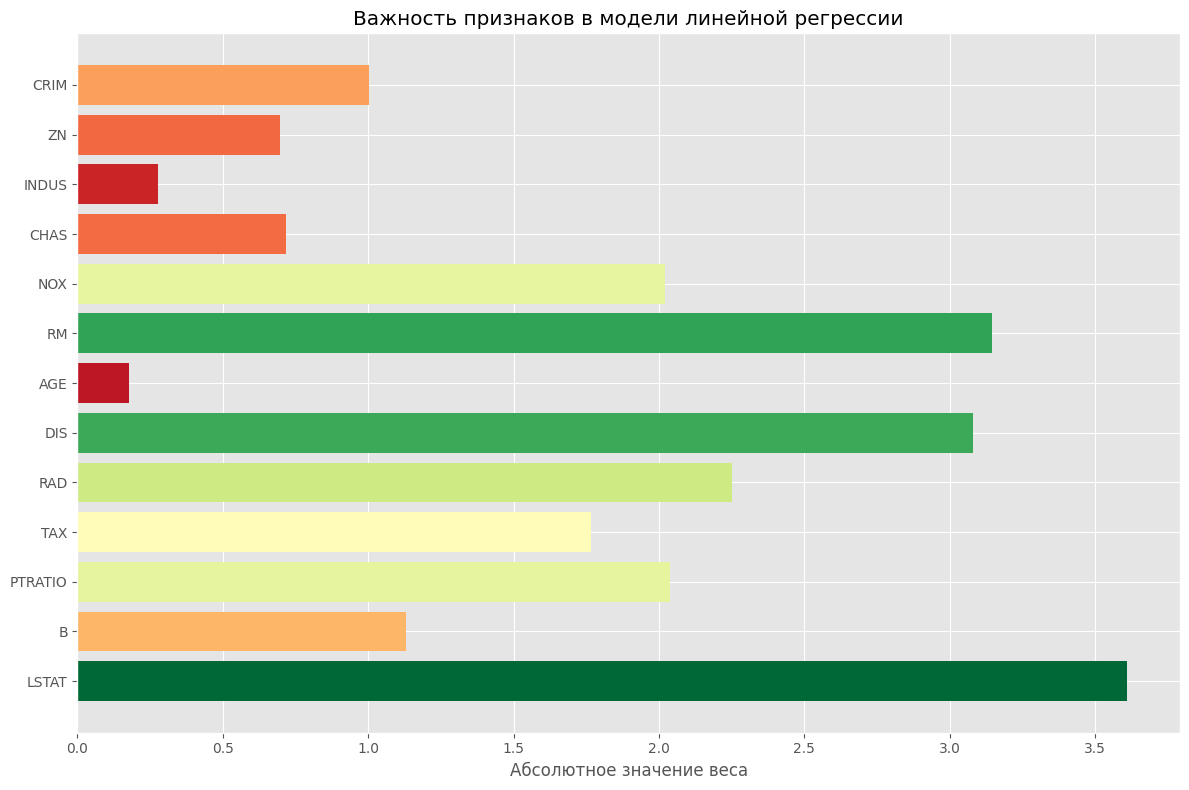


ИНТЕРПРЕТАЦИЯ:
   - Положительный вес: увеличение признака -> увеличение цены
   - Отрицательный вес: увеличение признака -> уменьшение цены
   - Чем больше |вес|, тем важнее признак


In [ ]:
print("\n" + "="*60)
print("ЗАДАНИЕ 3.7: ВАЖНОСТЬ ПРИЗНАКОВ")
print("="*60)

importance_df = pd.DataFrame({
    'Признак': X_boston.columns,
    'Вес (коэффициент)': model_full.coef_,
    'Важность (|вес|)': np.abs(model_full.coef_)
}).sort_values('Важность (|вес|)', ascending=False)

print("\nВАЖНОСТЬ ПРИЗНАКОВ (по убыванию):")
print("-"*70)
for i, row in importance_df.iterrows():
    stars = "*" * min(5, int(row['Важность (|вес|)'] / importance_df['Важность (|вес|)'].max() * 5) + 1)
    print(f"{row['Признак']:<12} | Вес: {row['Вес (коэффициент)']:>10.4f} | |Вес|: {row['Важность (|вес|)']:>10.4f} | {stars}")

plt.figure(figsize=(12, 8))
colors = plt.cm.RdYlGn(np.abs(model_full.coef_) / np.abs(model_full.coef_).max())
plt.barh(X_boston.columns, np.abs(model_full.coef_), color=colors)
plt.xlabel('Абсолютное значение веса')
plt.title('Важность признаков в модели линейной регрессии')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nИНТЕРПРЕТАЦИЯ:")
print("   - Положительный вес: увеличение признака -> увеличение цены")
print("   - Отрицательный вес: увеличение признака -> уменьшение цены")
print("   - Чем больше |вес|, тем важнее признак")

In [ ]:
print("\n" + "="*60)
print("ЗАДАНИЕ 3.8: ПОИСК АНОМАЛЬНО НИЗКИХ ЦЕН")
print("="*60)

test_predictions = model_sklearn_full.predict(X_test_scaled_sgd)

residuals = y_test_boston_array - test_predictions

threshold = residuals.std() * 2

anomaly_indices = np.where(residuals < -threshold)[0]

print(f"Порог для аномалий (2 std): {threshold:.4f}")
print(f"Стандартное отклонение остатков: {residuals.std():.4f}")
print(f"Найдено аномально низких цен: {len(anomaly_indices)}")

if len(anomaly_indices) > 0:
    print("\nАНОМАЛЬНО НИЗКИЕ ЦЕНЫ (реальная цена намного ниже предсказанной):")
    print("-"*80)
    print(f"{'Индекс':<8} {'Реальная цена':<15} {'Предсказанная':<15} {'Разница':<12}")
    print("-"*80)

    for idx in anomaly_indices[:10]:
        real_price = y_test_boston_array[idx]
        pred_price = test_predictions[idx]
        diff = real_price - pred_price
        print(f"{idx:<8} {real_price:<15.4f} {pred_price:<15.4f} {diff:<12.4f}")

    print("\nВОЗМОЖНЫЕ ПРИЧИНЫ АНОМАЛЬНО НИЗКИХ ЦЕН:")
    print("   1. Срочная продажа (нужда в быстрых деньгах)")
    print("   2. Плохое состояние недвижимости (не отражено в данных)")
    print("   3. Расположение в неблагополучном районе")
    print("   4. Ошибки в данных или опечатки")
    print("   5. Сезонные колебания рынка")
else:
    print("\nАномалий не найдено")


ЗАДАНИЕ 3.8: ПОИСК АНОМАЛЬНО НИЗКИХ ЦЕН
Порог для аномалий (2 std): 9.8459
Стандартное отклонение остатков: 4.9230
Найдено аномально низких цен: 1

АНОМАЛЬНО НИЗКИЕ ЦЕНЫ (реальная цена намного ниже предсказанной):
--------------------------------------------------------------------------------
Индекс   Реальная цена   Предсказанная   Разница     
--------------------------------------------------------------------------------
32       15.0000         25.9391         -10.9391    

ВОЗМОЖНЫЕ ПРИЧИНЫ АНОМАЛЬНО НИЗКИХ ЦЕН:
   1. Срочная продажа (нужда в быстрых деньгах)
   2. Плохое состояние недвижимости (не отражено в данных)
   3. Расположение в неблагополучном районе
   4. Ошибки в данных или опечатки
   5. Сезонные колебания рынка
